In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from gensim.models import Word2Vec
import pickle
import warnings
import re
from collections import Counter
from textblob import TextBlob
warnings.filterwarnings('ignore')

In [76]:
# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [77]:
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

True

In [78]:
data = pd.read_csv(r'C:\Users\Admin\PycharmProjects\MultipleSentimentLogistic\data\Sales_Final_Data_4770.csv', encoding='latin-1')

print("Shape:", data.shape)
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])


Shape: (4769, 2)
Rows: 4769
Columns: 2


In [79]:
#Null Values
print("Null Values per Column:")
print(data.isnull().sum())
print()
print("Total Nulls:", data.isnull().sum().sum())
print("Null %:", round(data.isnull().sum() / len(data) * 100, 2))

Null Values per Column:
Remarks      2
Sentiment    0
dtype: int64

Total Nulls: 2
Null %: Remarks      0.04
Sentiment    0.00
dtype: float64


In [24]:
# Display basic info
print("\n Dataset Info:")
print(data.info())


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4769 entries, 0 to 4768
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Remarks    4767 non-null   object
 1   Sentiment  4769 non-null   object
dtypes: object(2)
memory usage: 74.6+ KB
None


In [36]:
# Clean it properly
data = data.dropna(subset=['Remarks', 'Sentiment'])
data = data.drop_duplicates(subset=['Remarks'])
data['Sentiment'] = data['Sentiment'].str.strip().str.capitalize()
data = data[data['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

data_clean = data  # assigning data to clean data

print(f"Clean dataset shape: {data.shape}")
print(data['Sentiment'].value_counts())

Clean dataset shape: (3290, 2)
Sentiment
Neutral     1653
Negative    1307
Positive     330
Name: count, dtype: int64


Removes 286 null rows
✅ Removes 1,761 duplicates
✅ Normalizes label casing/spacing

<Axes: >

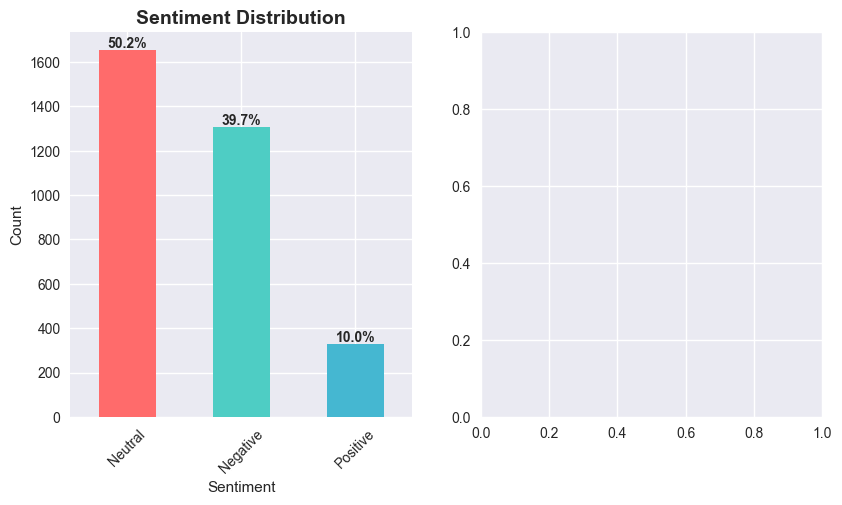

In [37]:
# Sentiment distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sentiment_counts = data_clean['Sentiment'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
sentiment_counts.plot(kind='bar', color=colors)
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add percentage labels on bars
for i, v in enumerate(sentiment_counts.values):
    percentage = (v / len(data_clean)) * 100
    plt.text(i, v + 10, f'{percentage:.1f}%', ha='center', fontweight='bold')

plt.subplot(1, 3, 2)


📏 Text Length Analysis:


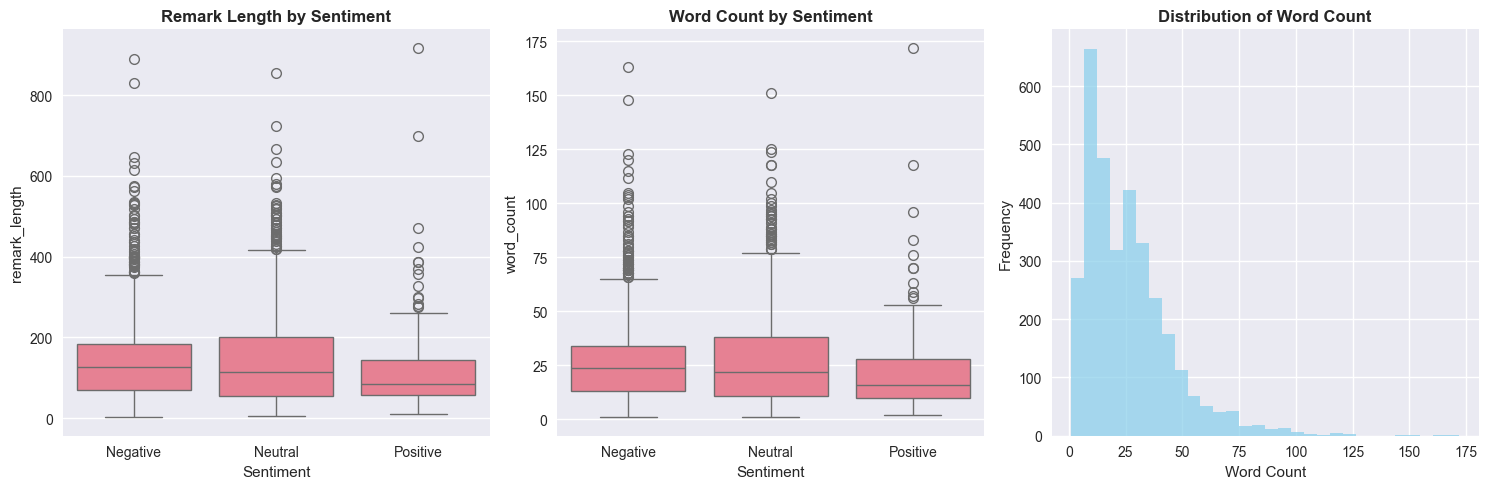

In [38]:
# Text length analysis
print("\n📏 Text Length Analysis:")
data_clean['remark_length'] = data_clean['Remarks'].str.len()
data_clean['word_count'] = data_clean['Remarks'].str.split().str.len()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=data_clean, x='Sentiment', y='remark_length')
plt.title('Remark Length by Sentiment', fontweight='bold')

plt.subplot(1, 3, 2)
sns.boxplot(data=data_clean, x='Sentiment', y='word_count')
plt.title('Word Count by Sentiment', fontweight='bold')

plt.subplot(1, 3, 3)
plt.hist(data_clean['word_count'], bins=30, alpha=0.7, color='skyblue')
plt.title('Distribution of Word Count', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [39]:
# Print statistics
for sentiment in data_clean['Sentiment'].unique():
    subset = data_clean[data_clean['Sentiment'] == sentiment]
    print(f"\n{sentiment.upper()} Sentiment:")
    print(f"  Average word count: {subset['word_count'].mean():.1f}")
    print(f"  Average character length: {subset['remark_length'].mean():.1f}")


NEGATIVE Sentiment:
  Average word count: 26.4
  Average character length: 142.6

NEUTRAL Sentiment:
  Average word count: 26.9
  Average character length: 141.9

POSITIVE Sentiment:
  Average word count: 20.6
  Average character length: 111.0


In [46]:
# TEXT PREPROCESSING FUNCTIONS
print("\n STEP 4: Text Preprocessing")
print("-" * 50)

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Text preprocessing - no stopword removal (custom sales model)"""
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters but keep spaces
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Only lemmatize — NO stopword removal (preserve "not", "no", "never" etc.)
    processed_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if len(token) > 1  # remove single chars only
    ]
    
    return ' '.join(processed_tokens)

# Apply preprocessing
print("Preprocessing text data...")
data_clean['processed_remarks'] = data_clean['Remarks'].apply(preprocess_text)

# Check preprocessing results
print("\nPreprocessing Examples:")
for i in range(3):
    print(f"\nOriginal:  {data_clean.iloc[i]['Remarks']}")
    print(f"Processed: {data_clean.iloc[i]['processed_remarks']}")



 STEP 4: Text Preprocessing
--------------------------------------------------
Preprocessing text data...

Preprocessing Examples:

Original:  Ashok (Vice President) Â confirmed using SAP. No plans for ERP change at the moment.
Processed: ashok vice president confirmed using sap no plan for erp change at the moment

Original:  Bhushan (IT Manager) Â using SAP B1. No major issues but open to info. Sent product overview via email.
Processed: bhushan it manager using sap b1 no major issue but open to info sent product overview via email

Original:  Chris Grant (Director of IT) Â asked not to be contacted further. Marked as do-not-call.
Processed: chris grant director of it asked not to be contacted further marked a do not call



☁ STEP 5: Word Cloud Generation
--------------------------------------------------


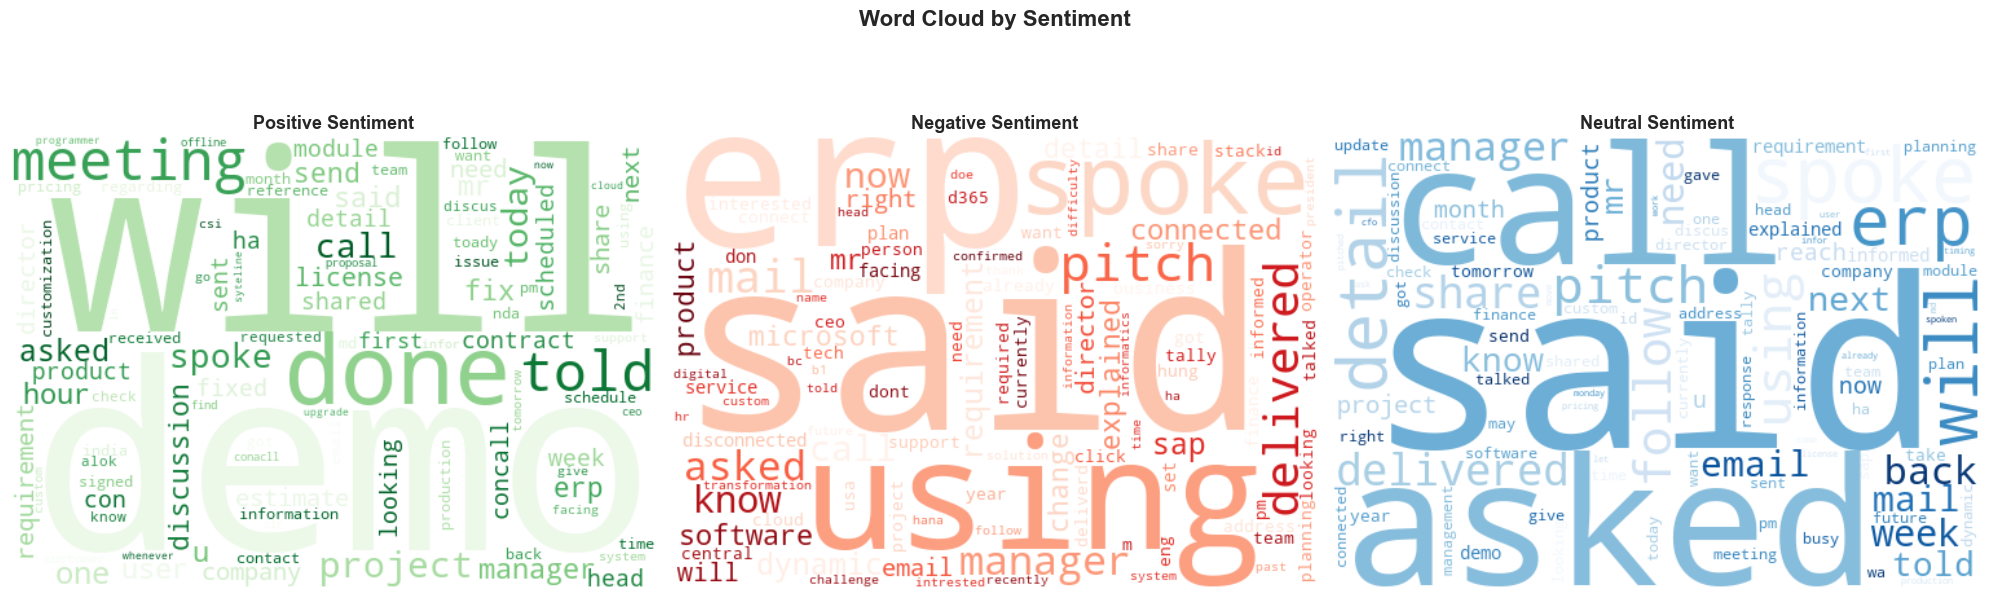

In [48]:
# 5. WORD CLOUD GENERATION
print("\n☁ STEP 5: Word Cloud Generation")
print("-" * 50)

# Color per sentiment
color_map = {
    'Positive': 'Greens',
    'Negative': 'Reds',
    'Neutral':  'Blues'
}

sentiments = ['Positive', 'Negative', 'Neutral']   # ← Capitalized to match data_clean

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Word Cloud by Sentiment', fontsize=16, fontweight='bold')

for ax, sentiment in zip(axes, sentiments):
    # Filter text for this sentiment
    text_data = ' '.join(
        data_clean[data_clean['Sentiment'] == sentiment]['processed_remarks'].dropna()
    )

    if text_data.strip():
        wc = WordCloud(
            width=500, height=350,
            background_color='white',
            colormap=color_map[sentiment],
            max_words=100,
            collocations=False
        ).generate(text_data)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{sentiment} Sentiment', fontsize=13, fontweight='bold')
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()



☁ Overall Word Cloud — All Sentiments Combined
--------------------------------------------------


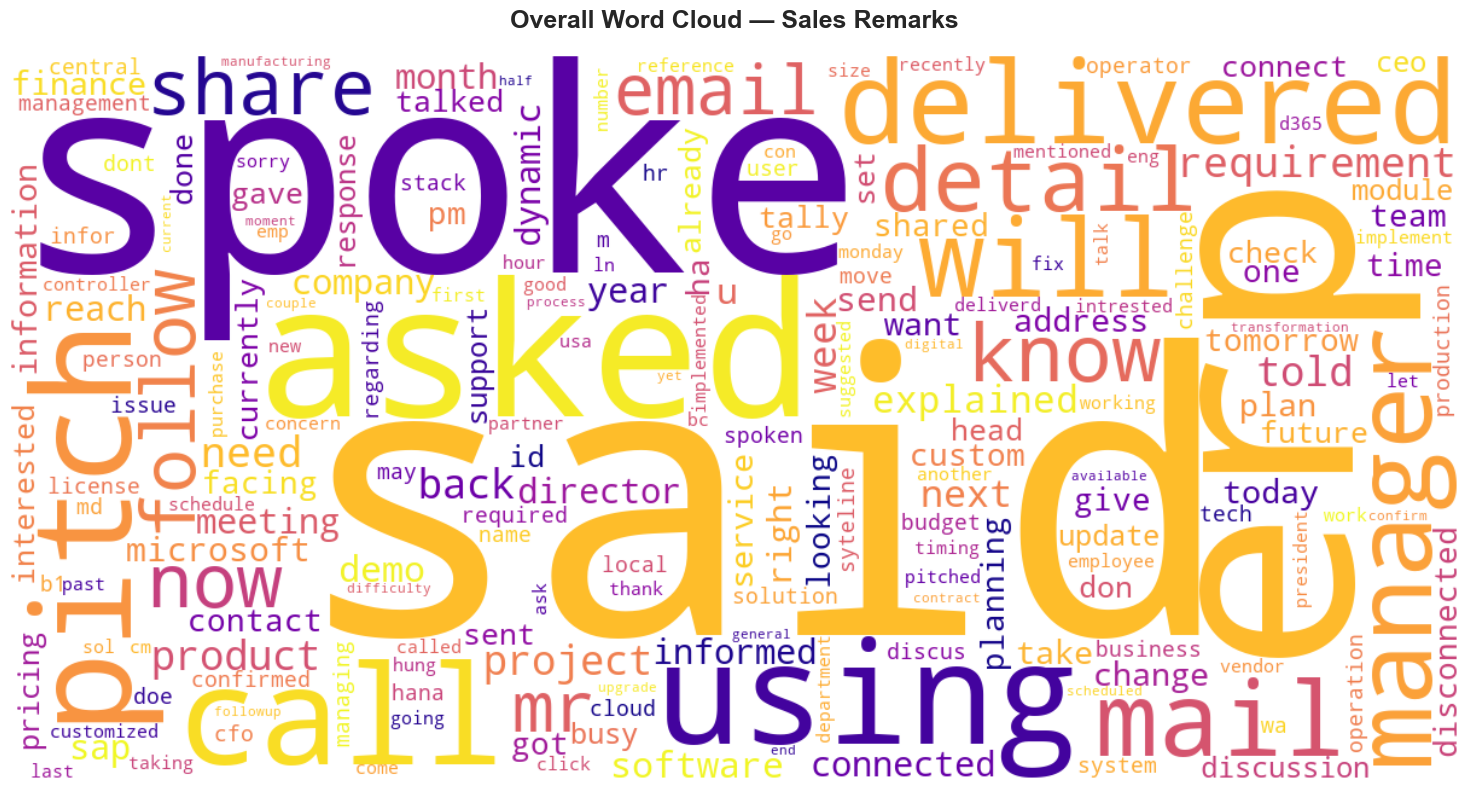


Total words used: 82415


In [50]:
# OVERALL WORD CLOUD
print("\n☁ Overall Word Cloud — All Sentiments Combined")
print("-" * 50)

all_text = ' '.join(data_clean['processed_remarks'].dropna())

overall_wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='plasma',
    max_words=200,
    collocations=False,
    prefer_horizontal=0.9
).generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(overall_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Word Cloud — Sales Remarks', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\nTotal words used: {len(all_text.split())}")



📊 STEP 6: Most Common Words Analysis
--------------------------------------------------


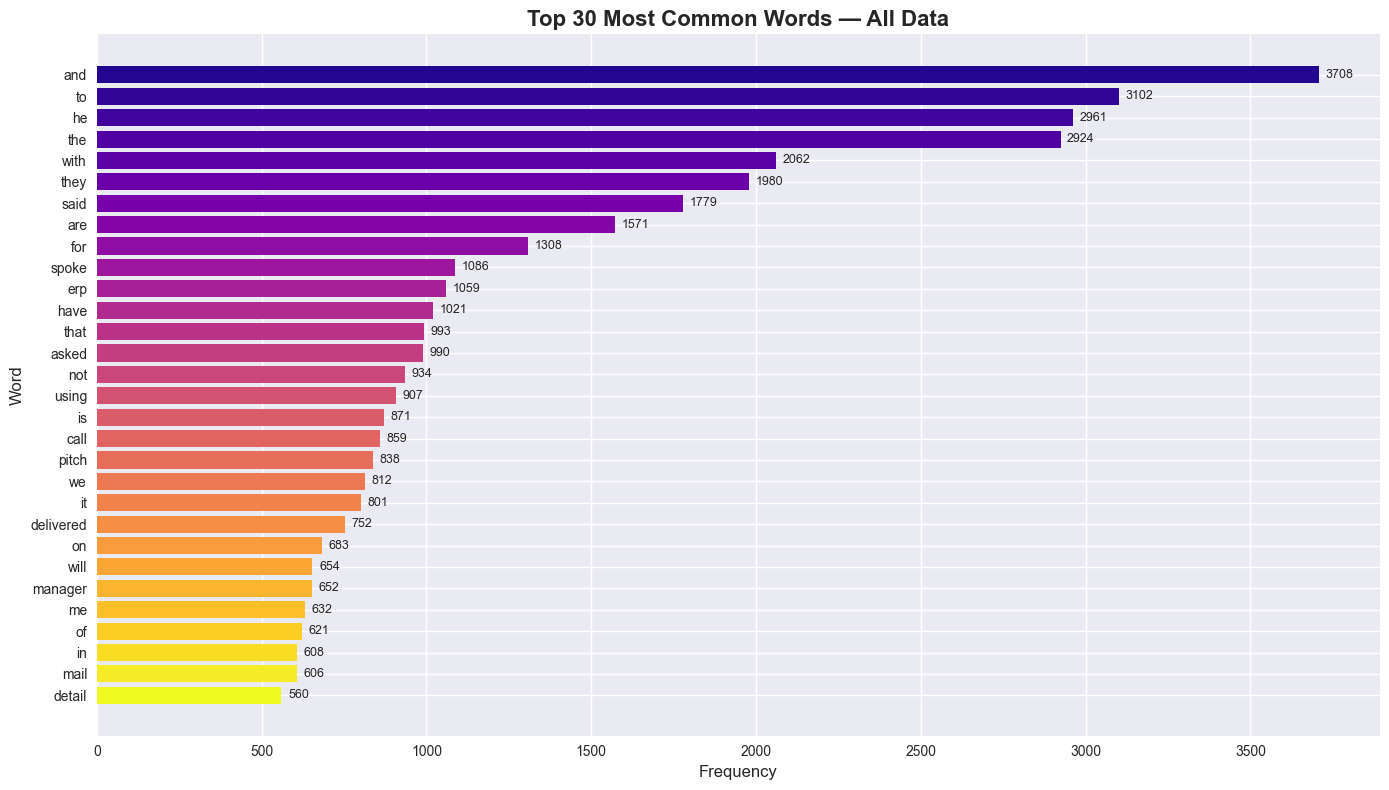

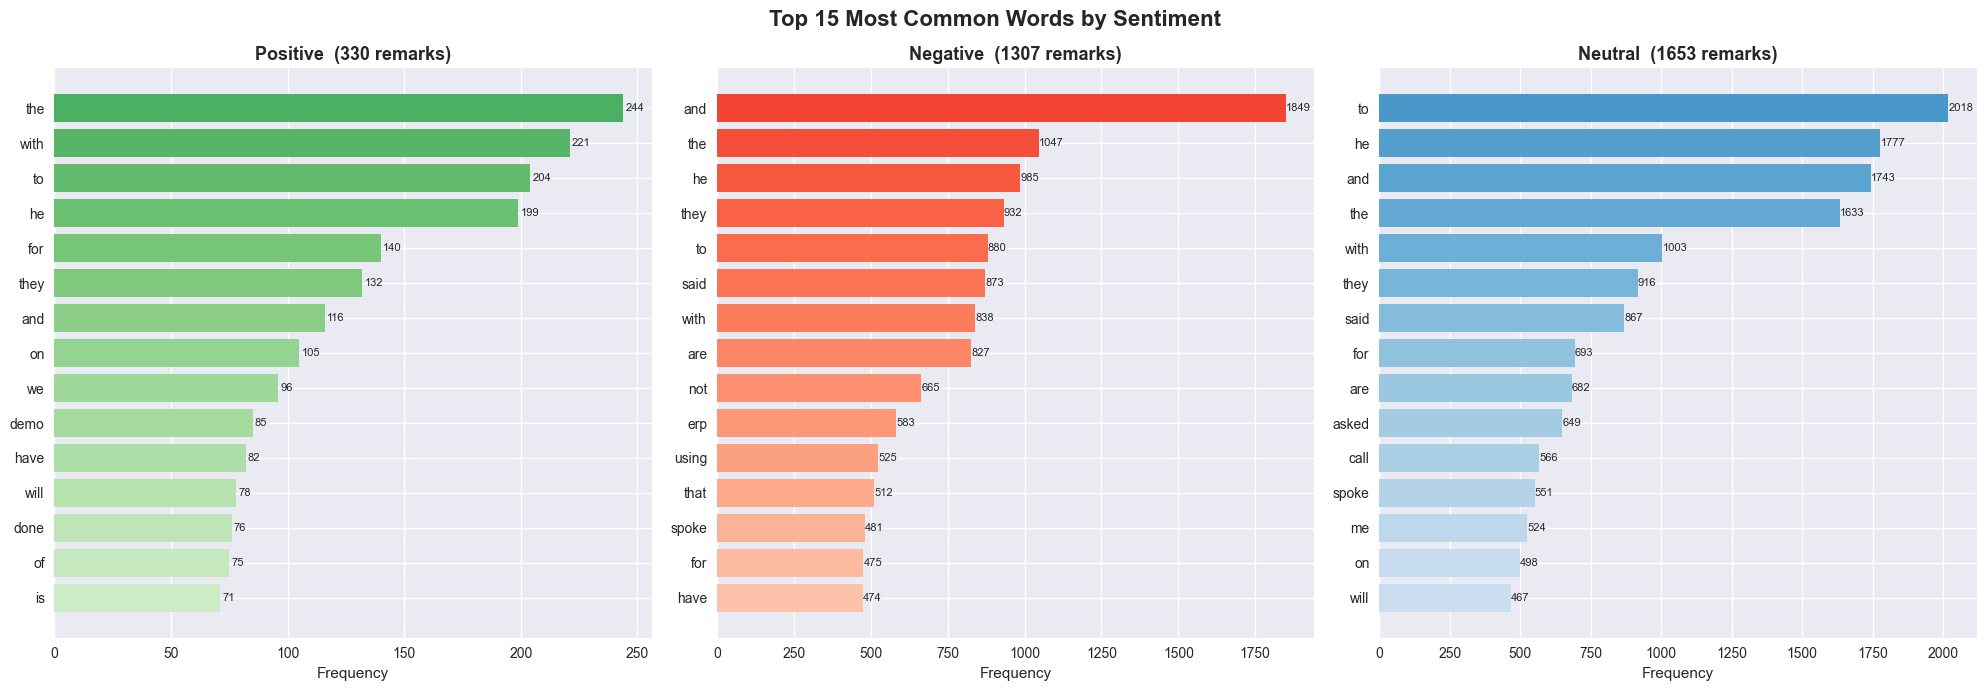


Top 20 Words Overall:
Rank   Word                 Count     
------------------------------------
1      and                  3708      
2      to                   3102      
3      he                   2961      
4      the                  2924      
5      with                 2062      
6      they                 1980      
7      said                 1779      
8      are                  1571      
9      for                  1308      
10     spoke                1086      
11     erp                  1059      
12     have                 1021      
13     that                 993       
14     asked                990       
15     not                  934       
16     using                907       
17     is                   871       
18     call                 859       
19     pitch                838       
20     we                   812       


In [52]:
# MOST COMMON WORDS ANALYSIS
print("\n📊 STEP 6: Most Common Words Analysis")
print("-" * 50)

from collections import Counter

# ── 1. Overall Top 30 Words (full size) ──────────────────────────
all_words = ' '.join(data_clean['processed_remarks'].dropna()).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(30)
words, counts = zip(*top_words)

plt.figure(figsize=(14, 8))
bars = plt.barh(list(words)[::-1], list(counts)[::-1],
                color=plt.cm.plasma_r([i/30 for i in range(30)]))
plt.title('Top 30 Most Common Words — All Data', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
for bar, count in zip(bars, list(counts)[::-1]):
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=9)
plt.tight_layout()
plt.show()

# ── 2. Top 15 Words Per Sentiment ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Top 15 Most Common Words by Sentiment', fontsize=16, fontweight='bold')

colors = {'Positive': 'Greens_r', 'Negative': 'Reds_r', 'Neutral': 'Blues_r'}

for ax, sentiment in zip(axes, ['Positive', 'Negative', 'Neutral']):
    subset = data_clean[data_clean['Sentiment'] == sentiment]['processed_remarks'].dropna()
    words_s = ' '.join(subset).split()
    freq = Counter(words_s).most_common(15)
    w, c = zip(*freq)

    cmap = plt.get_cmap(colors[sentiment])
    bar_colors = [cmap(0.4 + 0.4 * i / 15) for i in range(15)]
    ax.barh(list(w)[::-1], list(c)[::-1], color=bar_colors[::-1])
    ax.set_title(f'{sentiment}  ({len(subset)} remarks)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    for i, (word, count) in enumerate(zip(list(w)[::-1], list(c)[::-1])):
        ax.text(count + 1, i, str(count), va='center', fontsize=8)

plt.tight_layout()
plt.show()

# ── 3. Print summary table ───────────────────────────────────────
print("\nTop 20 Words Overall:")
print(f"{'Rank':<6} {'Word':<20} {'Count':<10}")
print("-" * 36)
for rank, (word, count) in enumerate(word_freq.most_common(20), 1):
    print(f"{rank:<6} {word:<20} {count:<10}")



🔬 STEP 6: Advanced NLP Analysis
--------------------------------------------------


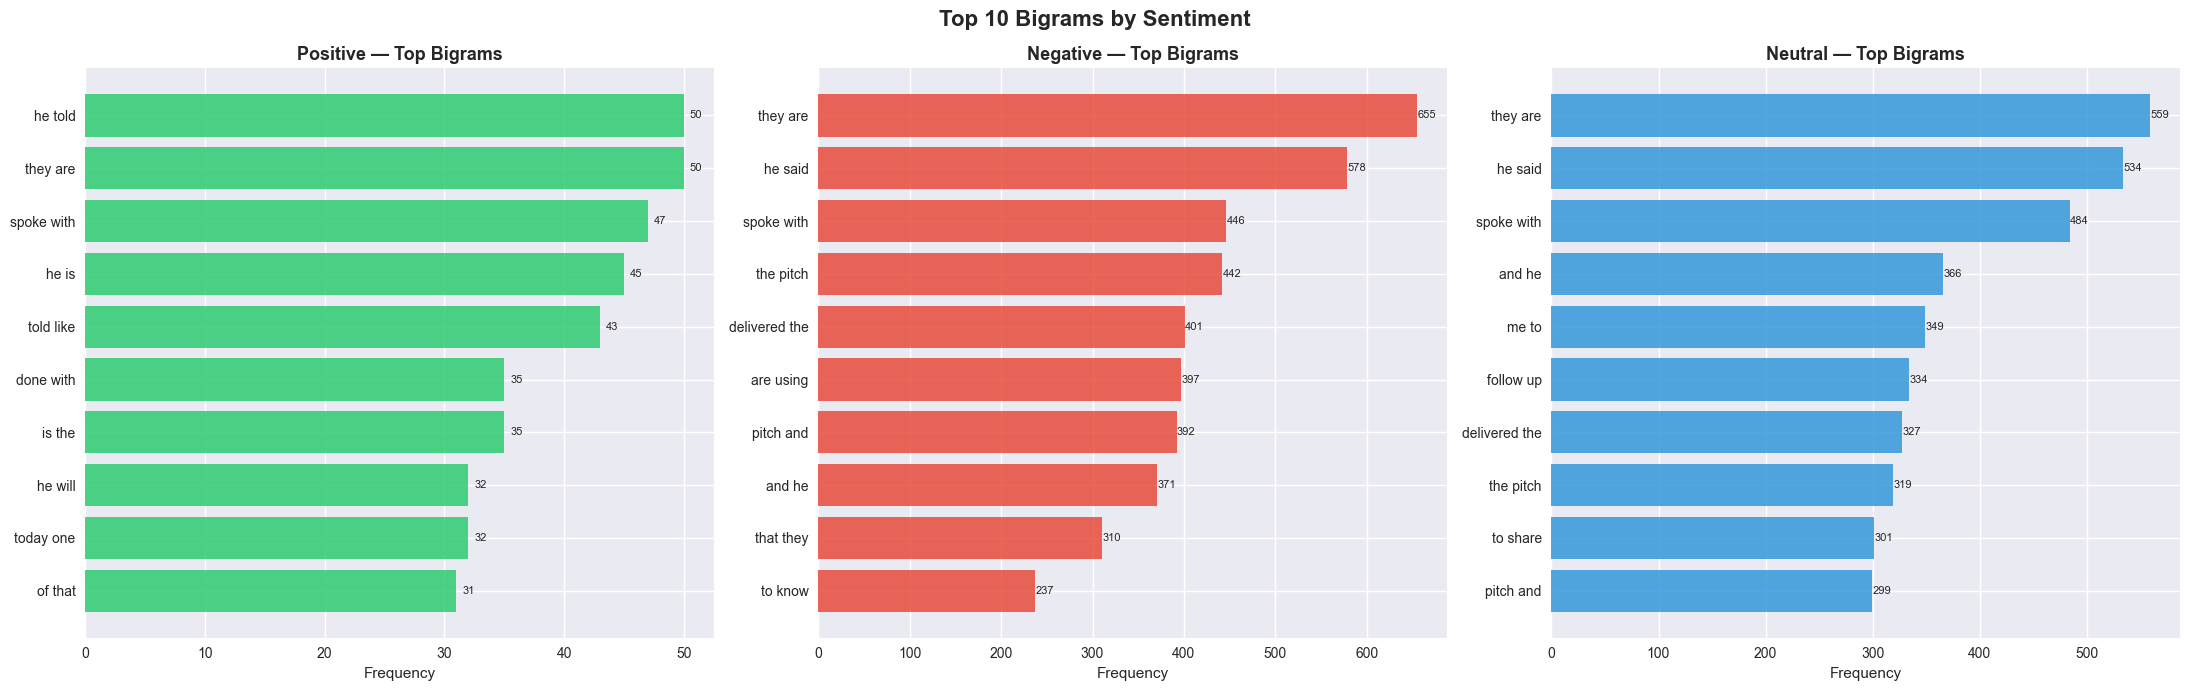

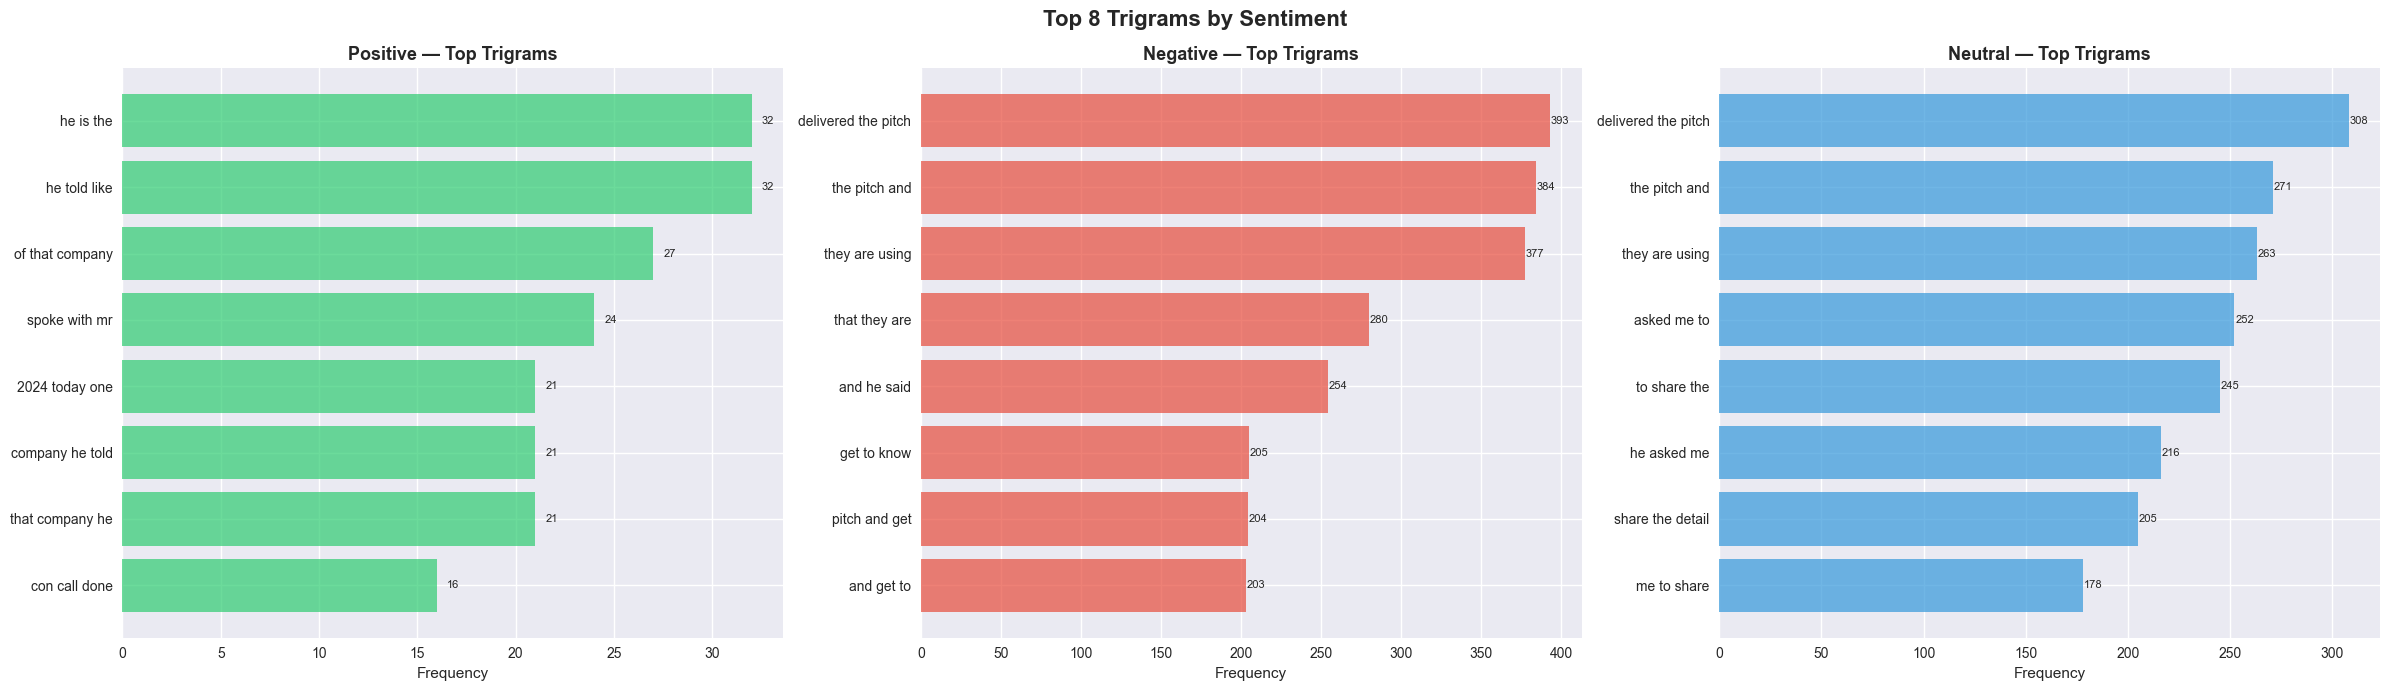

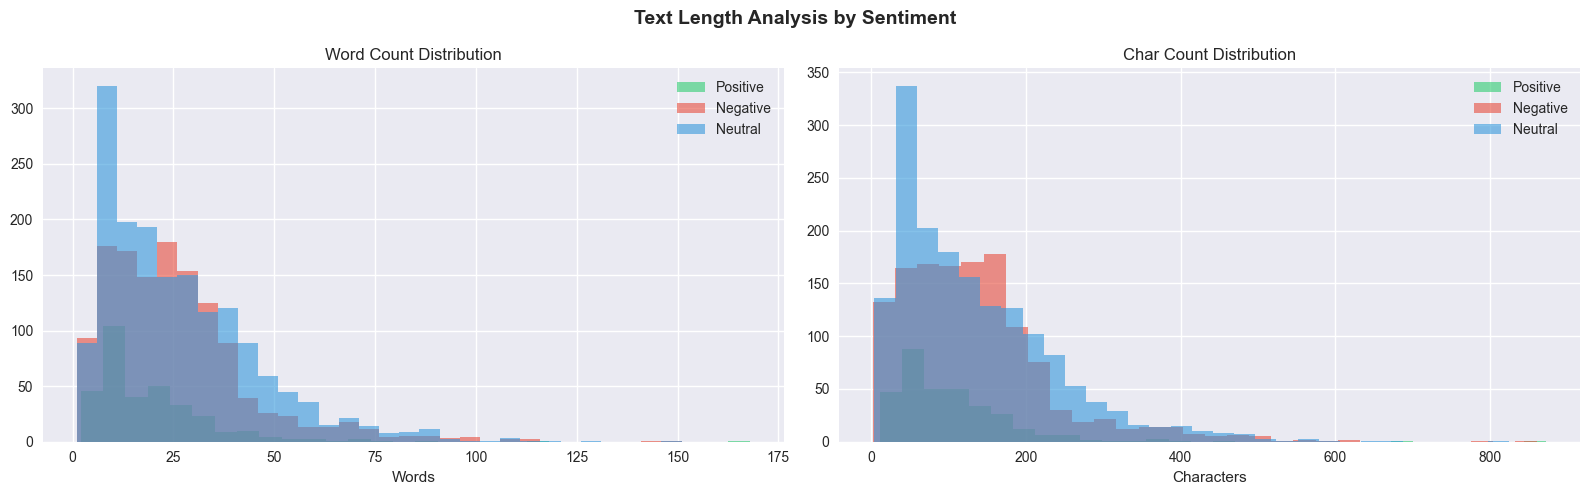


📌 Unique Vocabulary per Sentiment:
Sentiment    Remarks    Total Words    Unique Words   Avg Words/Remark
-----------------------------------------------------------------
Positive     330        6537           1093           19.8
Negative     1307       32839          2526           25.1
Neutral      1653       43039          3004           26.0


In [ ]:
# 6. ADVANCED NLP ANALYSIS
print("\n STEP 6: Advanced NLP Analysis")
print("-" * 50)

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# ── Helper: Top N-grams ───────────────────────────────────────────
def get_top_ngrams(text_series, n=2, top=10):
    """Get top n-grams from a text series"""
    text_series = text_series.dropna()
    if text_series.empty:
        return []
    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        max_features=1000
        # No stop_words — preserving negations for sales data
    )
    ngrams = vectorizer.fit_transform(text_series)
    feature_names = vectorizer.get_feature_names_out()
    ngram_counts = np.asarray(ngrams.sum(axis=0)).flatten()  # fix for newer scipy
    ngram_freq = sorted(zip(feature_names, ngram_counts), key=lambda x: x[1], reverse=True)
    return ngram_freq[:top]

# ── Fixed: Capitalized to match data_clean ────────────────────────
sentiments     = ['Positive', 'Negative', 'Neutral']
bar_colors     = ['#2ecc71',  '#e74c3c',  '#3498db']

# ── 1. BIGRAMS per Sentiment ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Top 10 Bigrams by Sentiment', fontsize=16, fontweight='bold')

for ax, sentiment, color in zip(axes, sentiments, bar_colors):
    subset = data_clean[data_clean['Sentiment'] == sentiment]['processed_remarks']
    top_bigrams = get_top_ngrams(subset, n=2, top=10)
    if top_bigrams:
        bigrams, counts = zip(*top_bigrams)
        ax.barh(list(bigrams)[::-1], list(counts)[::-1], color=color, alpha=0.85)
        ax.set_title(f'{sentiment} — Top Bigrams', fontsize=13, fontweight='bold')
        ax.set_xlabel('Frequency')
        for i, count in enumerate(list(counts)[::-1]):
            ax.text(count + 0.5, i, str(int(count)), va='center', fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
    ax.axis('on')

plt.tight_layout()
plt.show()

# ── 2. TRIGRAMS per Sentiment ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Top 8 Trigrams by Sentiment', fontsize=16, fontweight='bold')

for ax, sentiment, color in zip(axes, sentiments, bar_colors):
    subset = data_clean[data_clean['Sentiment'] == sentiment]['processed_remarks']
    top_trigrams = get_top_ngrams(subset, n=3, top=8)
    if top_trigrams:
        trigrams, counts = zip(*top_trigrams)
        ax.barh(list(trigrams)[::-1], list(counts)[::-1], color=color, alpha=0.7)
        ax.set_title(f'{sentiment} — Top Trigrams', fontsize=13, fontweight='bold')
        ax.set_xlabel('Frequency')
        for i, count in enumerate(list(counts)[::-1]):
            ax.text(count + 0.5, i, str(int(count)), va='center', fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')

plt.tight_layout()
plt.show()

# ── 3. Text Length Distribution per Sentiment ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Text Length Analysis by Sentiment', fontsize=14, fontweight='bold')

data_clean['word_count']  = data_clean['processed_remarks'].str.split().str.len()
data_clean['char_count']  = data_clean['processed_remarks'].str.len()

for sentiment, color in zip(sentiments, bar_colors):
    subset = data_clean[data_clean['Sentiment'] == sentiment]
    axes[0].hist(subset['word_count'].dropna(),  bins=30, alpha=0.6, label=sentiment, color=color)
    axes[1].hist(subset['char_count'].dropna(),  bins=30, alpha=0.6, label=sentiment, color=color)

axes[0].set_title('Word Count Distribution');  axes[0].set_xlabel('Words'); axes[0].legend()
axes[1].set_title('Char Count Distribution');  axes[1].set_xlabel('Characters'); axes[1].legend()
plt.tight_layout()
plt.show()

# ── 4. Unique Vocabulary per Sentiment ───────────────────────────
print("\n Unique Vocabulary per Sentiment:")
print(f"{'Sentiment':<12} {'Remarks':<10} {'Total Words':<14} {'Unique Words':<14} {'Avg Words/Remark'}")
print("-" * 65)
for sentiment in sentiments:
    subset = data_clean[data_clean['Sentiment'] == sentiment]['processed_remarks'].dropna()
    all_w  = ' '.join(subset).split()
    avg_w  = round(len(all_w) / len(subset), 1) if len(subset) > 0 else 0
    print(f"{sentiment:<12} {len(subset):<10} {len(all_w):<14} {len(set(all_w)):<14} {avg_w}")


In [55]:
# 7. FEATURE ENGINEERING
print("\n⚙️ STEP 7: Feature Engineering")
print("-" * 50)

# TF-IDF Vectorization
print("Creating TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,      # increased 10000, before 5000
    ngram_range=(1, 3),      # unigrams, bigrams, trigrams
    min_df=2,
    max_df=0.95,
    sublinear_tf=True        # added: reduces impact of very frequent words
    # stop_words removed — already handled in preprocess_text()
)

X_tfidf = tfidf_vectorizer.fit_transform(data_clean['processed_remarks'])
print(f"TF-IDF shape: {X_tfidf.shape}")




⚙️ STEP 7: Feature Engineering
--------------------------------------------------
Creating TF-IDF features...
TF-IDF shape: (3290, 10000)


In [56]:
# Label encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data_clean['Sentiment'])
print(f"Classes: {label_encoder.classes_}")


Classes: ['Negative' 'Neutral' 'Positive']


In [57]:
# Prepare sentences for Word2Vec
sentences = [remark.split() for remark in data_clean['processed_remarks']]


In [58]:
# Train Word2Vec model
print("Training Word2Vec model...")
word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

print(f"Word2Vec vocabulary size: {len(word2vec_model.wv.key_to_index)}")

# Test Word2Vec with sales-specific words
test_words = ['project', 'client', 'meeting', 'demo', 'contract']
print("\nWord2Vec Similarity Examples:")
for word in test_words:
    if word in word2vec_model.wv:
        similar_words = word2vec_model.wv.most_similar(word, topn=3)
        print(f"{word}: {similar_words}")

Training Word2Vec model...
Word2Vec vocabulary size: 2147

Word2Vec Similarity Examples:
project: [('assistance', 0.9158904552459717), ('doesnt', 0.9075397253036499), ('anything', 0.8945041298866272)]
client: [('same', 0.9894188642501831), ('feedback', 0.9891524910926819), ('handle', 0.9861288070678711)]
meeting: [('12pm', 0.914008378982544), ('sometimes', 0.8679367899894714), ('monday', 0.867868959903717)]
demo: [('timing', 0.8882289528846741), ('fresh', 0.8041684627532959), ('show', 0.7716378569602966)]
contract: [('signed', 0.9637354612350464), ('cancelled', 0.9568049907684326), ('hour', 0.9547449350357056)]


In [59]:
# 9. LSA (LATENT SEMANTIC ANALYSIS)
print("\n🔍 STEP 9: LSA Implementation")
print("-" * 50)

# Create LSA model
lsa_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_lsa = lsa_vectorizer.fit_transform(data_clean['processed_remarks'])

# Apply LSA
n_components = 50
lsa_model = TruncatedSVD(n_components=n_components, random_state=42)
X_lsa_transformed = lsa_model.fit_transform(X_lsa)

print(f"LSA components: {n_components}")
print(f"Explained variance ratio sum: {lsa_model.explained_variance_ratio_.sum():.3f}")


🔍 STEP 9: LSA Implementation
--------------------------------------------------
LSA components: 50
Explained variance ratio sum: 0.365


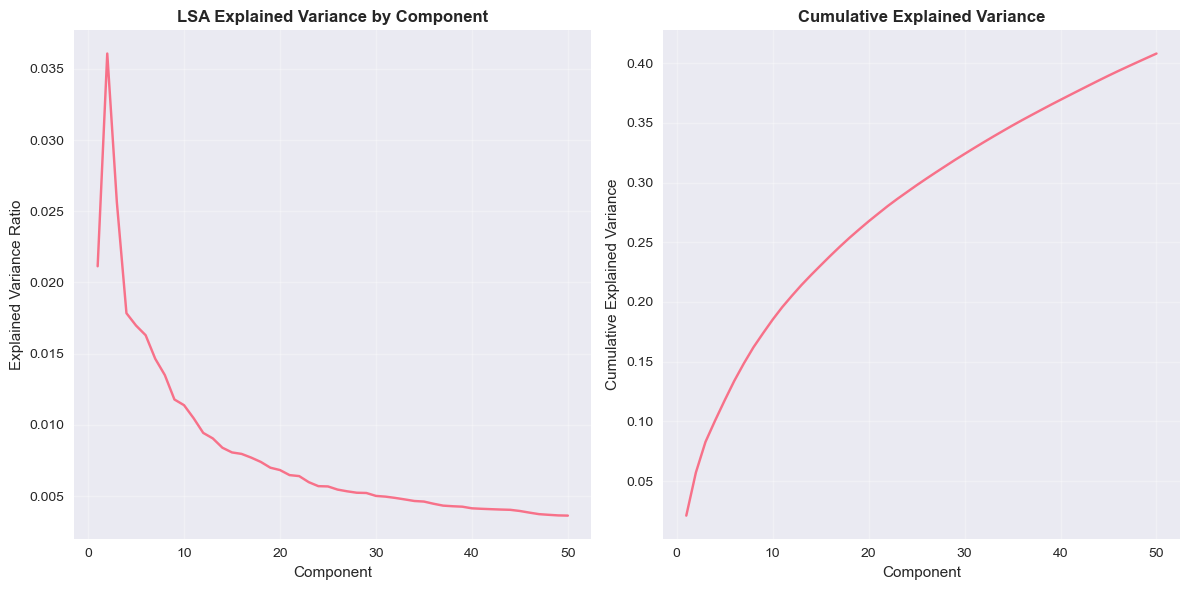

In [50]:
# Visualize LSA topics
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_components+1), lsa_model.explained_variance_ratio_)
plt.title('LSA Explained Variance by Component', fontweight='bold')
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cumsum_variance = np.cumsum(lsa_model.explained_variance_ratio_)
plt.plot(range(1, n_components+1), cumsum_variance)
plt.title('Cumulative Explained Variance', fontweight='bold')
plt.xlabel('Component')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
# 10. MODEL TRAINING AND EVALUATION
print("\n🤖 STEP 10: Logistic Regression Training")
print("-" * 50)

import os

# Keep original text aligned with TF-IDF split for error reporting
X_text   = data_clean['Remarks'].reset_index(drop=True)
y_labels = data_clean['Sentiment'].reset_index(drop=True)

# Split — now includes raw text alongside features
(X_train, X_test,
 y_train, y_test,
 text_train, text_test,
 label_train, label_test) = train_test_split(
    X_tfidf,
    y,
    X_text,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")

# Train Logistic Regression
best_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
best_model.fit(X_train, y_train)

# Predict
y_pred = best_model.predict(X_test)

# Decode numeric labels back to string labels
actual_labels    = label_encoder.inverse_transform(y_test)
predicted_labels = label_encoder.inverse_transform(y_pred)

# ── Wrong Prediction Report ───────────────────────────────────────
error_df = pd.DataFrame({
    "Remarks":   text_test.values,
    "Actual":    actual_labels,
    "Predicted": predicted_labels
})

# Focus: Positive rows predicted as Neutral (most damaging misclassification)
positive_as_neutral = error_df[
    (error_df["Actual"]    == "Positive") &
    (error_df["Predicted"] == "Neutral")
]

# Save report
reports_dir = r'C:\Users\Admin\PycharmProjects\MultipleSentimentLogistic\reports'
os.makedirs(reports_dir, exist_ok=True)
error_report_path = os.path.join(reports_dir, "positive_predicted_as_neutral.csv")
positive_as_neutral.to_csv(error_report_path, index=False)

print(f"\n⚠️  Positive predicted as Neutral count: {len(positive_as_neutral)}")
print(f"📄 Error report saved: {error_report_path}")

# Show sample misclassifications
print("\nSample Misclassified Rows:")
print(positive_as_neutral.head(10).to_string(index=False))

# Full classification report
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("\n📊 Classification Report:")
print(classification_report(actual_labels, predicted_labels))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")




🤖 STEP 10: Logistic Regression Training
--------------------------------------------------
Training set size: (2632, 10000)
Test set size:     (658, 10000)

⚠️  Positive predicted as Neutral count: 5
📄 Error report saved: C:\Users\Admin\PycharmProjects\MultipleSentimentLogistic\reports\positive_predicted_as_neutral.csv

Sample Misclassified Rows:
                                                                                                                                                                                                                                                                                                                                                             Remarks   Actual Predicted
                                                                                                                                                                                                                                                                                  

In [61]:
# Hyperparameter tuning
param_grid = {
     "C": [0.1, 0.5, 1, 3, 10],
     "solver": ["liblinear", "lbfgs"],
     "max_iter": [1000, 2000] 
     }


lr_model = LogisticRegression(
     random_state=42,
     class_weight="balanced",
     multi_class="auto"            # added multiclass='auto'
     )

grid_search = GridSearchCV( 
    lr_model, 
    param_grid, 
    cv=5, 
    scoring="f1_macro",            # scoring='f1_weighted
    n_jobs=-1 
    )

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best parameters: {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
Best cross-validation score: 0.8359


In [62]:
# Model evaluation
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")


Test Accuracy: 0.8693


In [63]:
# Cross-validation scores
cv_scores = cross_val_score(best_model, X_tfidf, y, cv=5, scoring="f1_macro")     # scoring='f1_weighted'

print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1 score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-validation F1 scores: [0.67698125 0.73995288 0.73606129 0.73421661 0.74199016]
Mean CV F1 score: 0.7258 (+/- 0.0492)


In [64]:
# Classification report
print("\n📊 Classification Report:")
class_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=class_names))


📊 Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.90      0.88       261
     Neutral       0.89      0.85      0.87       331
    Positive       0.80      0.85      0.82        66

    accuracy                           0.87       658
   macro avg       0.85      0.87      0.86       658
weighted avg       0.87      0.87      0.87       658



Text(122.31597222222221, 0.5, 'Actual')

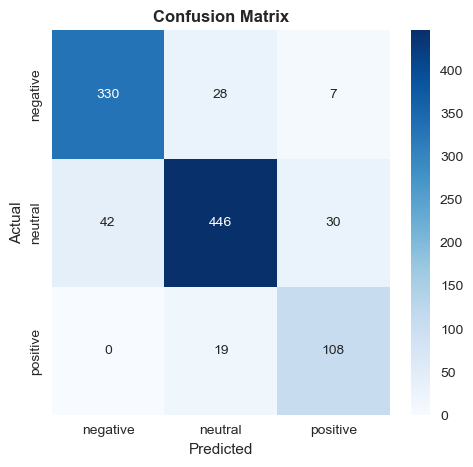

In [58]:
# Confusion matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [66]:
# Create semantic similarity function
def find_similar_remarks(input_text, data, vectorizer, top_k=5):
    """Find semantically similar remarks"""
    processed_input = preprocess_text(input_text)
    input_vector = vectorizer.transform([processed_input])
    
    all_vectors = vectorizer.transform(data['processed_remarks'])
    similarities = (input_vector * all_vectors.T).toarray()[0]
    
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        if similarities[idx] > 0:
            results.append({
                'remark': data.iloc[idx]['Remarks'],
                'sentiment': data.iloc[idx]['Sentiment'],
                'similarity': similarities[idx]
            })
    
    return results

# Test semantic similarity
test_inputs = [
    "client signed the contract",
    "customer rejected our proposal", 
    "need to follow up next week"
]

print("Semantic Similarity Examples:")
for test_input in test_inputs:
    print(f"\nInput: '{test_input}'")
    similar = find_similar_remarks(test_input, data_clean, tfidf_vectorizer, top_k=3)
    for i, sim in enumerate(similar, 1):
        print(f"  {i}. [{sim['sentiment']}] {sim['remark'][:100]}... (similarity: {sim['similarity']:.3f})")

Semantic Similarity Examples:

Input: 'client signed the contract'
  1. [Positive] The first contract is signed... (similarity: 0.392)
  2. [Positive] 500 hours Comprehensive Contract signed with AB electronics... (similarity: 0.273)
  3. [Positive] 100 Hours Contract Signed for Comprehensive Managed Services... (similarity: 0.251)

Input: 'customer rejected our proposal'
  1. [Positive] Revised proposal shared.... (similarity: 0.404)
  2. [Neutral] Followup regarding Proposal... (similarity: 0.343)
  3. [Positive] Had a discussion with Akilan and proposal reshared... (similarity: 0.298)

Input: 'need to follow up next week'
  1. [Neutral] We have to follow up next week... (similarity: 0.752)
  2. [Neutral] need to follow up... (similarity: 0.643)
  3. [Neutral] Need to follow up... (similarity: 0.643)


In [69]:
# 12. MODEL SAVING
# Save main model components
with open('C:/Users/Admin/PycharmProjects/MultipleSentimentLogistic/app/models/New_Updated_Models/sentiment_model_4770.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("✓ Logistic Regression model saved")

✓ Logistic Regression model saved


In [70]:
with open('C:/Users/Admin/PycharmProjects/MultipleSentimentLogistic/app/models/New_Updated_Models/tfidf_vectorizer_4770.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f) 
print("✓ TF-IDF vectorizer saved")

✓ TF-IDF vectorizer saved


In [71]:
with open('C:/Users/Admin/PycharmProjects/MultipleSentimentLogistic/app/models/New_Updated_Models/label_encoder_4770.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✓ Label encoder saved")

✓ Label encoder saved


In [72]:
# Save Word2Vec model
word2vec_model.save('C:/Users/Admin/PycharmProjects/MultipleSentimentLogistic/app/models/New_Updated_Models/word2vec_sales_4770.model')
print("✓ Word2Vec model saved")

✓ Word2Vec model saved


In [73]:
# Save LSA components
with open('C:/Users/Admin/PycharmProjects/MultipleSentimentLogistic/app/models/New_Updated_Models/lsa_model_4770.pkl', 'wb') as f:
    pickle.dump(lsa_model, f)
print("✓ LSA model saved")

✓ LSA model saved


In [74]:
with open('C:/Users/Admin/PycharmProjects/MultipleSentimentLogistic/app/models/New_Updated_Models/lsa_vectorizer_4770.pkl', 'wb') as f:
    pickle.dump(lsa_vectorizer, f)
print("✓ LSA vectorizer saved")

✓ LSA vectorizer saved


In [69]:
# 13. FINAL SUMMARY
print("\n🎯 STEP 13: Final Summary")
print("-" * 50)

summary_stats = {
    'Total Records': len(data_clean),
    'Features (TF-IDF)': X_tfidf.shape[1],
    'Model Accuracy': f"{accuracy:.4f}",
    'CV F1 Score': f"{cv_scores.mean():.4f}",
    'Sentiment Distribution': dict(data_clean['Sentiment'].value_counts()),
    'Average Words per Remark': f"{data_clean['word_count'].mean():.1f}",
    'Word2Vec Vocab Size': len(word2vec_model.wv.key_to_index),
    'LSA Components': n_components,
    'LSA Explained Variance': f"{lsa_model.explained_variance_ratio_.sum():.3f}"
}

print("📈 Model Performance Summary:")
for key, value in summary_stats.items():
    print(f"  {key}: {value}")


🎯 STEP 13: Final Summary
--------------------------------------------------
📈 Model Performance Summary:
  Total Records: 5049
  Features (TF-IDF): 5000
  Model Accuracy: 0.8752
  CV F1 Score: 0.7656
  Sentiment Distribution: {'neutral': 2589, 'negative': 1827, 'positive': 633}
  Average Words per Remark: 23.3
  Word2Vec Vocab Size: 2689
  LSA Components: 50
  LSA Explained Variance: 0.408


In [70]:
# Performance by sentiment class
print("\n📊 Performance by Sentiment Class:")
for i, class_name in enumerate(class_names):
    class_mask = y_test == i
    if np.sum(class_mask) > 0:
        class_accuracy = accuracy_score(y_test[class_mask], y_pred[class_mask])
        print(f"  {class_name.title()}: {class_accuracy:.4f}")

print("\n🎉 Enhanced Sales Sentiment Analysis System Ready!")
print("✓ Logistic Regression with semantic understanding")
print("✓ Word2Vec embeddings for semantic similarity")
print("✓ LSA for topic-based analysis")
print("✓ Sales-specific lexicon and POS tagging")
print("✓ Contextual modifiers (negation, intensifiers)")
print("✓ FastAPI integration ready")


📊 Performance by Sentiment Class:
  Negative: 0.9041
  Neutral: 0.8610
  Positive: 0.8504

🎉 Enhanced Sales Sentiment Analysis System Ready!
✓ Logistic Regression with semantic understanding
✓ Word2Vec embeddings for semantic similarity
✓ LSA for topic-based analysis
✓ Sales-specific lexicon and POS tagging
✓ Contextual modifiers (negation, intensifiers)
✓ FastAPI integration ready


In [68]:
print(y_test.shape)
print(y_train.shape)

(658,)
(2632,)
